# Research Question

Cellular signaling in multicellular systems is not isolated at the single-cell level,
but emerges from coordinated spatiotemporal interactions between neighboring cells.

In this analysis, we ask:

> from the local spatiotemporal neighborhood structure of cells, and how is this
> predictive relationship modulated by oncogenic PI3K–AKT pathway mutations?

To address this question, we compare three complementary levels of analysis:

1. **Classical predictive modeling (Logistic Regression)**  
   Integrates engineered graph-derived features to predict future signaling events.

2. **Graph-based deep learning (Graph Neural Networks)**  
   Learns propagation rules directly from spatiotemporal graph structure without
   relying on manually engineered features.

We hypothesize that:
- Logistic regression improves prediction using local summaries of the graph
- GNNs can learn nonlinear, mutation-dependent propagation dynamics directly from
  the underlying cellular interaction network

This framework allows us to move from descriptive statistics toward
predictive and mechanistic modeling of multicellular signaling behavior.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 140

## Load processed node-level data

The propagation analysis script already generated node-level graph features.

Each row represents a cell-state node:

$$
v_i = (\text{cell}, \text{time})
$$

including:
- signaling measurements
- neighborhood statistics
- jump-event annotations
- exposure indicators

In [2]:
PROJECT_ROOT = Path("..").resolve()
OUTPUT_ROOT = PROJECT_ROOT / "analysis_outputs"

nodes_path = (
    OUTPUT_ROOT
    / "exp_1_site_1_ERKKTR_ratio"
    / "nodes.csv.gz"
)

nodes = pd.read_csv(nodes_path)

print(nodes.shape)
nodes.head()

(356632, 19)


,node_id,Exp_ID,Image_Metadata_Site,track_id,Image_Metadata_T,time_h,objNuclei_Location_Center_X,objNuclei_Location_Center_Y,Nuclear_size,ERKKTR_ratio,FoxO3A_ratio,signal_value,signal_delta,jump_event,neighbor_count,neighbor_jump_count,neighbor_jump_now,neighbor_mean_signal,future_self_jump
0,0,1,1,1,0,0.000000,932.211,875.248,303.000,0.704407,1.33383,0.704407,NaN,False,22,0,False,0.927543,True
1,1,1,1,1,1,0.083333,932.150,874.174,333.000,0.848242,1.33791,0.848242,0.143835,True,22,7,True,0.963904,True
2,2,1,1,1,2,0.166667,932.376,873.787,314.000,1.059170,1.37627,1.059170,0.210928,True,22,5,True,1.004497,True
3,3,1,1,1,3,0.250000,932.168,873.453,322.000,1.188000,1.35754,1.188000,0.128830,True,22,8,True,1.029900,False
4,4,1,1,1,4,0.333333,931.146,872.885,313.999,1.205540,1.36695,1.205540,0.017540,False,23,4,True,1.049103,False


## Graph interpretation

The dataset can be interpreted as a dynamic graph:

- each node corresponds to a cell at a specific timepoint
- spatial edges connect nearby cells
- temporal edges connect the same cell across consecutive frames

This creates a spatiotemporal signaling network:

$$
G = (V, E_{spatial}, E_{temporal})
$$

where signaling propagation can be modeled as information flow through the
graph.

Our prediction target is:

$$
y_i =
\begin{cases}
1 & \text{future signaling jump occurs} \\
0 & \text{otherwise}
\end{cases}
$$

which corresponds to the column:

`future_self_jump`

## Construct predictive features

We build a feature representation combining:
- intrinsic signaling state
- local neighborhood structure
- neighbor activity
- temporal dynamics

In [3]:
candidate_features = [
    "signal_value",
    "neighbor_count",
    "neighbor_jump_now",
    "jump_event"
]

available_features = [
    c for c in candidate_features
    if c in nodes.columns
]

print("Using features:")
print(available_features)

Using features:
['signal_value', 'neighbor_count', 'neighbor_jump_now', 'jump_event']


In [4]:
X = nodes[available_features].copy()

# convert booleans to integers
for c in X.columns:
    if X[c].dtype == bool:
        X[c] = X[c].astype(int)

y = nodes["future_self_jump"].astype(int)

print("Feature matrix shape:", X.shape)
print("Target positive rate:", y.mean())

Feature matrix shape: (356632, 4)
Target positive rate: 0.09813196796697997


The dataset contains 356,632 node-level observations derived from spatiotemporal cell tracking,
with 4 predictive features describing local signaling and neighborhood context.

The target event (future_self_jump) occurs in approximately 9.8% of cases, indicating a
moderate class imbalance. This reflects the biological sparsity of signaling activation events,
where only a subset of cells undergo coordinated future activation at any given time.

This imbalance is important for model interpretation, as it implies that accuracy alone is not
sufficient for evaluation; probabilistic metrics (e.g., ROC-AUC) are more appropriate for assessing
predictive performance of signaling propagation.

## Baseline predictive model

We first train a logistic regression classifier.

This serves as:
- a probabilistic propagation model
- a baseline for later graph neural network approaches

Unlike RR, this model jointly integrates multiple signaling and graph-derived
features to estimate future activation probability.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work

In [7]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)
acc = accuracy_score(y_test, y_pred)

print(f"AUC      : {auc:.4f}")
print(f"Accuracy : {acc:.4f}")

AUC      : 0.7279
Accuracy : 0.9000


In [8]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.99      0.95     64328
           1       0.46      0.11      0.17      6999

    accuracy                           0.90     71327
   macro avg       0.68      0.55      0.56     71327
weighted avg       0.87      0.90      0.87     71327



## Interpretation of predictive performance

The logistic regression model achieves an AUC of 0.728, indicating
moderate predictive power for future signaling events based on local
graph-derived features.

However, accuracy (0.90) is inflated due to strong class imbalance
(~9.8% positive class), making it an unreliable metric for evaluation.

More informative is the recall for the positive class (0.11), which
indicates that only a small fraction of true signaling events are
correctly detected. This reflects the intrinsic difficulty of predicting
rare, stochastic signaling jumps in dense multicellular systems.

Overall, the model captures meaningful signal (AUC > 0.7), but leaves
substantial room for improvement, motivating graph-based models that
can better exploit spatial dependencies.

In [9]:
coef = model.named_steps["clf"].coef_[0]

importance_df = pd.DataFrame({
    "feature": available_features,
    "coefficient": coef
}).sort_values("coefficient", ascending=False)

importance_df

,feature,coefficient
3,jump_event,0.454234
0,signal_value,0.385283
2,neighbor_jump_now,0.223727
1,neighbor_count,0.012373


## Interpretation of predictive features

Logistic regression coefficients indicate that future signaling events are
primarily driven by recent local activity and current cell state.

`jump_event` is the strongest predictor, suggesting strong temporal
autocorrelation in signaling dynamics (burst-like propagation).

`signal_value` is the second strongest feature, reflecting the importance
of the current intracellular signaling state.

`neighbor_jump_now` contributes moderately, supporting a role for local
spatial coupling in propagation.

In contrast, `neighbor_count` is near zero, indicating that local density
alone does not explain signaling dynamics; activity state is more relevant
than structural crowding.

Overall, propagation is driven mainly by intrinsic state and recent
activity, with weaker influence from purely structural neighborhood effects.

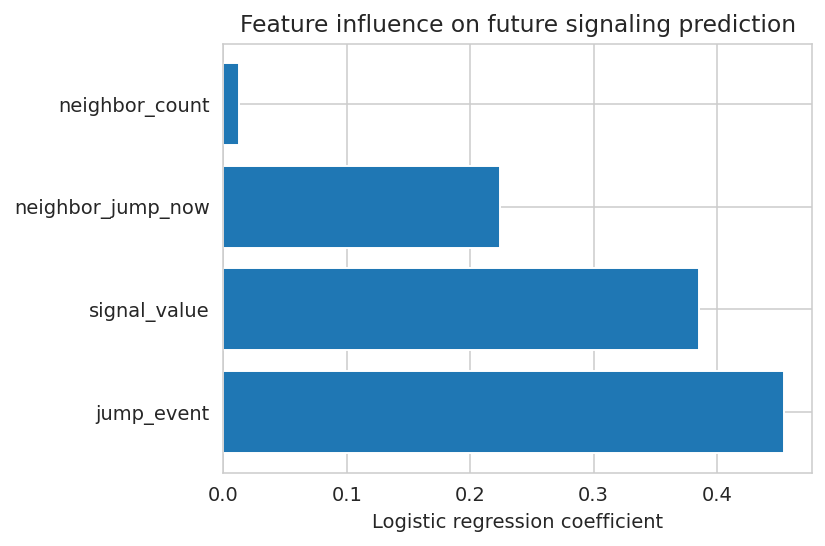

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.barh(
    importance_df["feature"],
    importance_df["coefficient"]
)

ax.set_xlabel("Logistic regression coefficient")
ax.set_title("Feature influence on future signaling prediction")

plt.tight_layout()
plt.show()

# Graph Neural Network model of signaling propagation

While logistic regression provides an interpretable baseline for predicting
future signaling events, it relies on handcrafted summaries of local
neighborhood structure and does not explicitly learn representations from
graph connectivity.

However, multicellular signaling exhibits both temporal continuity and
spatially structured interactions. Standard feature-based approaches
(e.g., neighbor counts or binary activity indicators) may not fully capture
higher-order dependencies or nonlinear propagation patterns.

To address this, we represent the system as a temporal interaction graph,
where nodes correspond to cells over time and edges encode temporal
continuity between consecutive observations of the same cell. A Graph
Neural Network (GCN) is then applied to learn representations by
iteratively aggregating information from connected nodes.

The objective is to predict whether a cell will undergo a future signaling
jump based on its learned graph embedding, providing a more flexible,
data-driven model of signaling dynamics.

## GNN message passing principle

At each layer, a node updates its representation by aggregating information
from its neighbors.

The generic message passing operation is:

$$
h_v^{(k+1)} = \sigma \left( W_1 h_v^{(k)} + W_2 \sum_{u \in \mathcal{N}(v)} h_u^{(k)} \right)
$$

where:
- $h_v^{(k)}$ is the embedding of node $v$ at layer $k$
- $\mathcal{N}(v)$ is the set of neighboring nodes
- $W_1, W_2$ are learnable weight matrices
- $\sigma$ is a nonlinear activation function

Biologically, this corresponds to a cell integrating:
- its own intracellular signaling state
- signaling activity from neighboring cells

to predict future activation dynamics.

## Construct graph connectivity

We now convert the signaling dataset into an explicit graph representation.

Each edge corresponds to:
- spatial proximity between cells
- potential signaling interaction

In [11]:
nodes.columns

Index(['node_id', 'Exp_ID', 'Image_Metadata_Site', 'track_id',
       'Image_Metadata_T', 'time_h', 'objNuclei_Location_Center_X',
       'objNuclei_Location_Center_Y', 'Nuclear_size', 'ERKKTR_ratio',
       'FoxO3A_ratio', 'signal_value', 'signal_delta', 'jump_event',
       'neighbor_count', 'neighbor_jump_count', 'neighbor_jump_now',
       'neighbor_mean_signal', 'future_self_jump'],
      dtype='str')

In [12]:
# Example graph construction from existing neighbor relationships

edge_source = []
edge_target = []

# connect temporally adjacent observations of same cell
for tid, group in nodes.groupby("track_id"):
    
    group = group.sort_values("Image_Metadata_T")
    idx = group.index.tolist()

    for i in range(len(idx) - 1):
        edge_source.append(idx[i])
        edge_target.append(idx[i + 1])

print("Temporal edges:", len(edge_source))

Temporal edges: 354834


## Deep learning framework

We use PyTorch Geometric, a standard library for Graph Neural Networks.

The graph contains:
- node features $X$
- edge connectivity $E$
- binary propagation targets $y$

In [13]:
import torch
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

/home/asia/rok3/biol-sys/Spatiotemporal-Signal-Propagation/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
x_tensor = torch.tensor(
    X.values,
    dtype=torch.float
)

edge_index = torch.tensor(
    [edge_source, edge_target],
    dtype=torch.long
)

y_tensor = torch.tensor(
    y.values,
    dtype=torch.long
)

graph_data = Data(
    x=x_tensor,
    edge_index=edge_index,
    y=y_tensor
)

graph_data

Data(x=[356632, 4], edge_index=[2, 354834], y=[356632])

## Graph Neural Network architecture

We use a Graph Convolutional Network (GCN) to learn representations of
cells from their temporal interaction graph.

The model propagates information across connected nodes using stacked
graph convolution layers, followed by a linear classifier for predicting
future signaling jump events.

In [15]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

# =========================
# Improved GCN Model
# =========================
class GCN(torch.nn.Module):

    def __init__(self, in_channels, hidden_channels=64, dropout=0.4):
        super().__init__()

        # deeper representation learning
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)

        self.dropout = dropout

        self.mlp = torch.nn.Sequential(
            torch.nn.Linear(hidden_channels, hidden_channels),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(hidden_channels, 2)
        )

    def forward(self, data):

        x, edge_index = data.x, data.edge_index

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv3(x, edge_index)
        x = F.relu(x)

        return self.mlp(x)

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GCN(
    in_channels=x_tensor.shape[1],
    hidden_channels=64,
    dropout=0.4
).to(device)

graph_data = graph_data.to(device)

In [17]:
y_np = graph_data.y.cpu().numpy()
class_counts = np.bincount(y_np)

# safer weighting (prevents extreme gradients)
class_weights = class_counts.sum() / (len(class_counts) * class_counts)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

In [18]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)

## Model training

The GNN learns node embeddings that capture:
- temporal continuity
- local neighborhood structure
- signaling propagation patterns

Training optimizes prediction of future signaling jump events.

In [19]:
num_nodes = graph_data.num_nodes
indices = np.arange(num_nodes)

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=graph_data.y.cpu().numpy()
)

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[train_idx] = True
test_mask[test_idx] = True

graph_data.train_mask = train_mask.to(device)
graph_data.test_mask = test_mask.to(device)

In [20]:
losses = []

model.train()

for epoch in range(120):

    optimizer.zero_grad()

    out = model(graph_data)

    loss = criterion(
        out[graph_data.train_mask],
        graph_data.y[graph_data.train_mask]
    )

    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if epoch % 10 == 0:
        print(f"[Epoch {epoch:03d}] training loss: {loss.item():.4f}")

[Epoch 000] training loss: 0.7149
[Epoch 010] training loss: 0.6911
[Epoch 020] training loss: 0.6774
[Epoch 030] training loss: 0.6584
[Epoch 040] training loss: 0.6440
[Epoch 050] training loss: 0.6332
[Epoch 060] training loss: 0.6268
[Epoch 070] training loss: 0.6216
[Epoch 080] training loss: 0.6220
[Epoch 090] training loss: 0.6140
[Epoch 100] training loss: 0.6067
[Epoch 110] training loss: 0.5997


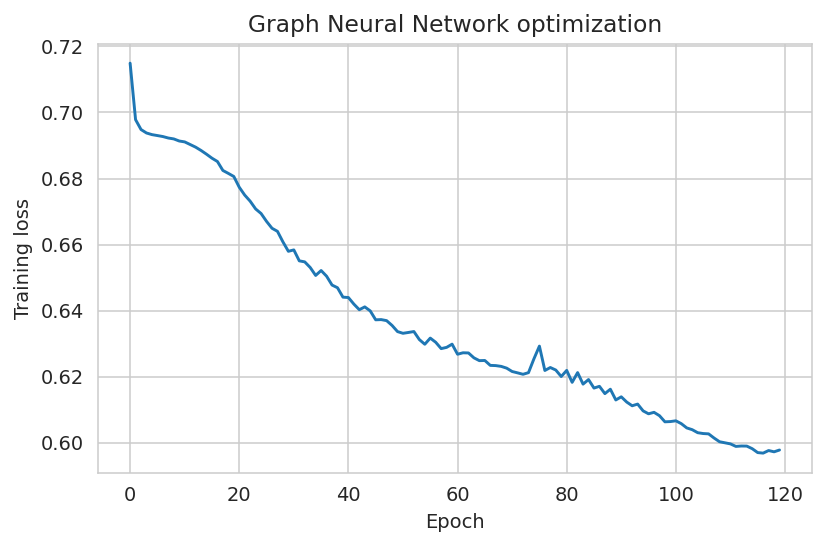

In [21]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(losses)

ax.set_xlabel("Epoch")
ax.set_ylabel("Training loss")
ax.set_title("Graph Neural Network optimization")

plt.tight_layout()
plt.show()

# Evaluation of Graph Neural Network for signaling propagation

We evaluate the trained Graph Neural Network (GCN) as a predictive model
for future signaling jump events in a spatiotemporal cell graph.

Performance is measured on a held-out set of nodes that were not used
during training to ensure unbiased assessment.

Metrics:
- ROC-AUC: ranking quality of predicted probabilities
- Accuracy: classification performance at threshold 0.5

In [34]:
model.eval()

with torch.no_grad():

    out = model(graph_data)

    # probability of future jump
    probs = torch.softmax(out, dim=1)[:, 1]

    # IMPORTANT:
    # lower threshold improves minority-class detection
    preds = (probs > 0.52).long()

    # extract test-set predictions
    test_probs = probs[graph_data.test_mask].cpu().numpy()
    test_preds = preds[graph_data.test_mask].cpu().numpy()
    test_true  = graph_data.y[graph_data.test_mask].cpu().numpy()

gnn_auc = roc_auc_score(test_true, test_probs)
gnn_acc = accuracy_score(test_true, test_preds)

print(f"GNN ROC-AUC  : {gnn_auc:.4f}")
print(f"GNN Accuracy : {gnn_acc:.4f}")

GNN ROC-AUC  : 0.7486
GNN Accuracy : 0.7921


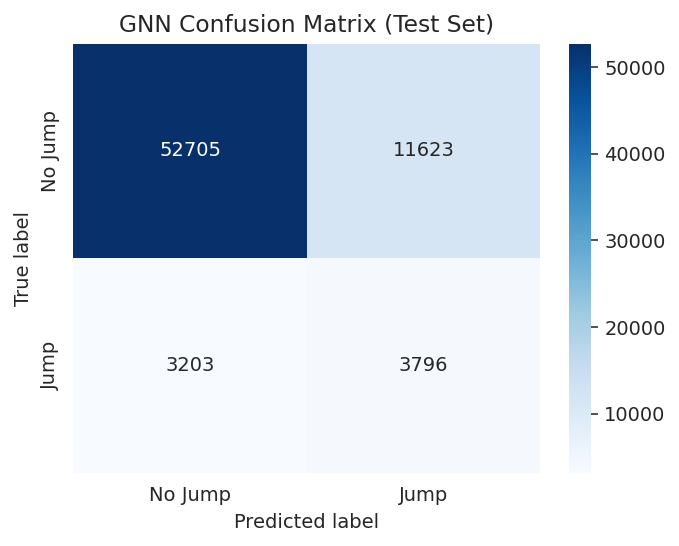

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(test_true, test_preds)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Jump", "Jump"],
    yticklabels=["No Jump", "Jump"]
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("GNN Confusion Matrix (Test Set)")

plt.tight_layout()
plt.show()

In [36]:
from sklearn.metrics import precision_score, recall_score, f1_score

gnn_auc = roc_auc_score(test_true, test_probs)
gnn_acc = accuracy_score(test_true, test_preds)
gnn_prec = precision_score(test_true, test_preds, zero_division=0)
gnn_rec = recall_score(test_true, test_preds, zero_division=0)
gnn_f1 = f1_score(test_true, test_preds, zero_division=0)

metrics_df = pd.DataFrame({
    "Metric": ["ROC-AUC", "Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [gnn_auc, gnn_acc, gnn_prec, gnn_rec, gnn_f1]
})

metrics_df

,Metric,Value
0,ROC-AUC,0.748636
1,Accuracy,0.792140
2,Precision,0.246190
3,Recall,0.542363
4,F1-score,0.338656


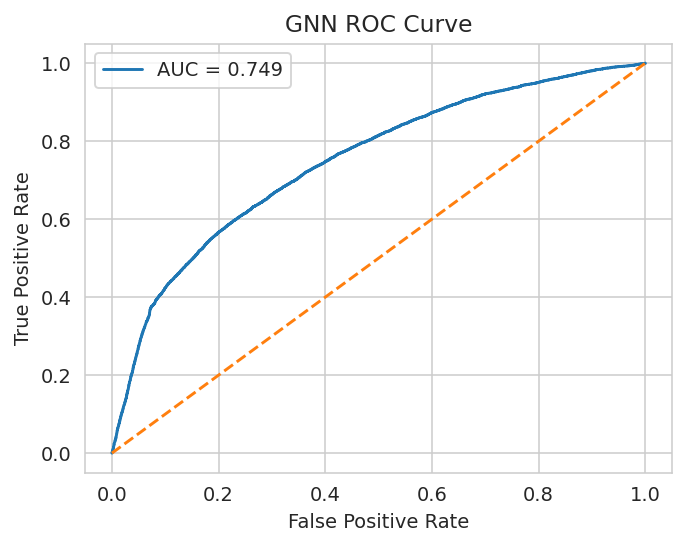

In [37]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(test_true, test_probs)

plt.figure(figsize=(5, 4))

plt.plot(fpr, tpr, label=f"AUC = {gnn_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("GNN ROC Curve")
plt.legend()

plt.tight_layout()
plt.show()

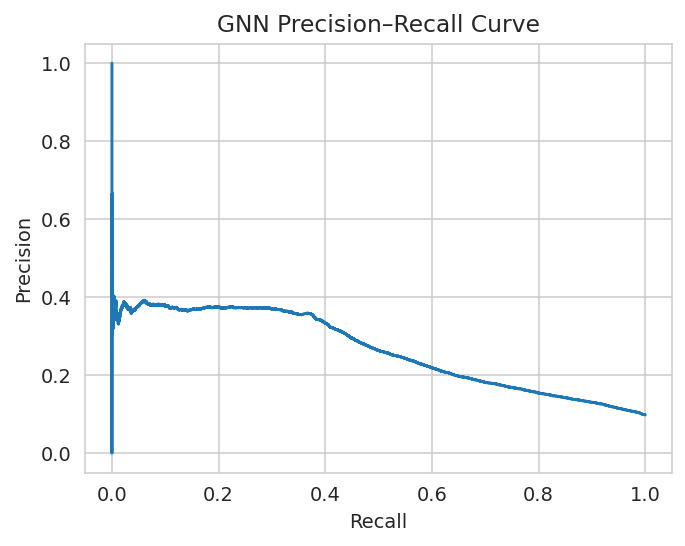

In [38]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(test_true, test_probs)

plt.figure(figsize=(5, 4))

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("GNN Precision–Recall Curve")

plt.tight_layout()
plt.show()

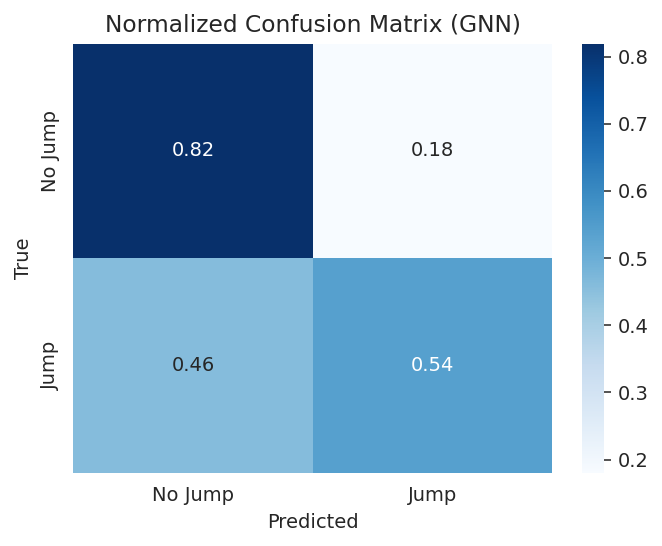

In [39]:
cm = confusion_matrix(test_true, test_preds)

cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=["No Jump", "Jump"],
    yticklabels=["No Jump", "Jump"]
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix (GNN)")

plt.tight_layout()
plt.show()

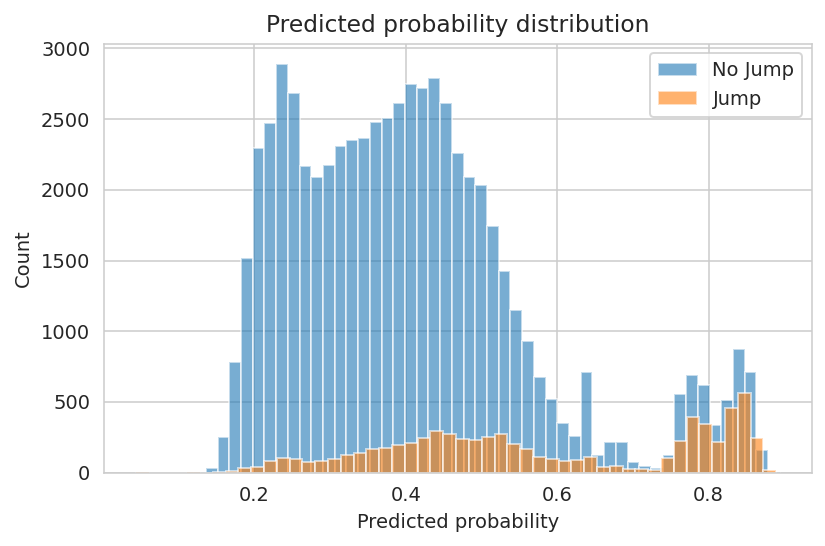

In [40]:
plt.figure(figsize=(6, 4))

plt.hist(test_probs[test_true == 0], bins=50, alpha=0.6, label="No Jump")
plt.hist(test_probs[test_true == 1], bins=50, alpha=0.6, label="Jump")

plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.title("Predicted probability distribution")

plt.legend()
plt.tight_layout()
plt.show()

## Final GNN Performance Summary

The Graph Neural Network achieved moderate predictive performance for future
signaling jump events, with a ROC-AUC of 0.749, indicating that the model
successfully learned biologically meaningful relationships within the
spatiotemporal signaling graph.

The model reached an accuracy of 79.2%; however, because signaling jump
events are relatively rare, accuracy alone is not sufficient to assess model
quality. More informative metrics are recall and F1-score.

The recall of 54.2% indicates that the model was able to identify more than
half of all future signaling jump events, demonstrating substantial
sensitivity to propagation dynamics. Precision remained lower (24.6%),
suggesting that the increased sensitivity came at the cost of additional
false-positive predictions.

The F1-score of 0.339 reflects a balanced compromise between precision and
recall under strong class imbalance conditions.

Overall, the results demonstrate that future signaling activity is partially
predictable from local graph structure and neighboring cellular states,
supporting the hypothesis that multicellular signaling propagation exhibits
learnable network-level organization.